Universidad de Palermo | Procesamiento Del Lenguaje Natural

# Trabajo práctico integrador

Integrantes:
- Juan Cruz Rey
- Juan Ignacio Pintarelli
- Mateo Chiza
- Paula Goldenhorn

---

#### Introducción

En entornos educativos, especialmente en clases presenciales, es frecuente que surjan incidencias operativas que interrumpen el desarrollo normal de la actividad. Entre los problemas más comunes se encuentran la falta de tinta en marcadores para pizarra, fallas en computadoras, problemas con el aire acondicionado, entre otras. Estas situaciones generan demoras, ya que el docente debe interrumpir la clase, buscar asistencia en recepción u otra área, volver al aula y esperar la resolución del inconveniente.

El problema que aborda este proyecto es la necesidad de reducir ese tiempo de respuesta mediante un sistema que permita al docente registrar rápidamente la incidencia en lenguaje natural y que, a partir de ese mensaje, se genere automáticamente un ticket estructurado con la información relevante. Por ejemplo, ante un mensaje como “no tengo marcadores en el aula 4”, el sistema debería identificar el objeto afectado, el lugar y el problema, y producir una salida estructurada lista para su gestión.

El enfoque asumido consiste en desarrollar un sistema de procesamiento de lenguaje natural basado en reconocimiento de entidades nombradas (NER), orientado a un dominio específico con un vocabulario determinado. Se trata de una solución simple, pero efectiva, centrada en reconocer un conjunto reducido de entidades relevantes.

#### Criterios de éxito

En el contexto de este problema, un falso positivo (FP) ocurre cuando el modelo detecta una entidad inexistente o asigna incorrectamente una etiqueta a un fragmento del texto, mientras que un falso negativo (FN) sucede cuando el sistema no reconoce una entidad relevante presente en el mensaje del usuario. Maximizar la precisión implica reducir la cantidad de falsos positivos, priorizando que las entidades detectadas sean correctas, mientras que maximizar el recall busca reducir los falsos negativos, favoreciendo que la mayor cantidad posible de entidades relevantes sea identificada por el modelo.
En el contexto del sistema propuesto, resulta relevante maximizar el recall del modelo, ya que los falsos negativos implican la pérdida de información al omitir entidades como el objeto afectado o la ubicación del problema. Aunque los falsos positivos pueden introducir ruido en la salida, generalmente permiten conservar suficiente información contextual para que el ticket siga siendo interpretable. Por este motivo, se priorizó un equilibrio entre precisión y recall, con especial atención en minimizar los falsos negativos, es decir, entidades omitidas durante la extracción.



## 1. Carga del Dataset sintético

El conjunto de datos empleado para este proyecto fue creado sintéticamente. Se incluyeron tanto ejemplos basados en situaciones reales como frases simuladas, también ejemplos sin etiquetar y mensajes que no tienen las tres entidades posibles (por ejemplo, objeto y problema pero no explicitan el lugar). Se creó una cantidad de ejemplos y etiquetas de forma manual y con herramientas de Inteligencia Artificial se aumentó el tamaño del dataset.  

El conjunto de datos tiene 570 ejemplos anotados con tres tipos de entidades:
* OBJETO, que representa el elemento afectado (por ejemplo, “marcador”, “proyector”)
* PROBLEMA, que describe la incidencia (como “no funciona”, “está roto”)
* LUGAR, que indica la ubicación donde ocurre el problema (por ejemplo, “aula 04-05” o “biblioteca”).

In [ ]:
# == Constantes Google Drive ==
DATASET_LIMPIO = "1sRYWn2nA8ni18VrapNiB5bivfEZTRYBa" # dataset_limpio_fixed.jsonl
CONFIGURACION_MODELO = "1v4wrHKDKtgO1dClim8qweaRrL-CsBTyK" # config es_core_news_lg
CONFIGURACION_MODELO_CHICO = "1dc9kO8FUefC1-O90uC5u-jv_d0wGu-_T" # config es_core_news_sm

In [ ]:
# == Herramientas ==
!pip install -q gdown

import ast
import json
import os
import warnings

import gdown
import srsly

from sklearn.model_selection import train_test_split

import spacy
from spacy.tokens import DocBin
from spacy.training import offsets_to_biluo_tags


In [ ]:
# == Se descarga el dataset desde Google Drive y se guarda como "dataset_limpio.json" ==
gdown.download(id=DATASET_LIMPIO, output="dataset_limpio.jsonl", quiet=False)

TRAIN_DATA = [(row["text"], {"entities": row["entities"]}) for row in srsly.read_jsonl("dataset_limpio.jsonl")]

print(f"Dataset cargado: {len(TRAIN_DATA)} ejemplos")

Downloading...
From: https://drive.google.com/uc?id=1sRYWn2nA8ni18VrapNiB5bivfEZTRYBa
To: /content/dataset_limpio.jsonl
100%|██████████| 72.3k/72.3k [00:00<00:00, 37.0MB/s]

Dataset cargado: 570 ejemplos


In [ ]:
# == Guardado del dataset en formato JSON ==
output_file = "dataset_limpio.jsonl"
with open(output_file, "w", encoding="utf-8") as f:
    for text, ann in TRAIN_DATA:
        f.write(json.dumps({"text": text, "entities": ann["entities"]}, ensure_ascii=False) + "\n")

print(f"Dataset guardado en {output_file}")

Dataset guardado en dataset_limpio.jsonl


## 2. Instalación de spaCy

In [ ]:
# == spaCy ==
!pip install -q spacy

# == Modelo ==
!python -m spacy download es_core_news_lg --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 1.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# == Muestra del dataset ==
with open("dataset_limpio.jsonl", "r", encoding="utf-8") as f:
    primeros_caracteres = f.read(200)
print(primeros_caracteres)

{"text": "El borrador de la pizarra está roto en el aula 02-04", "entities": [[3, 11, "OBJETO"], [26, 35, "PROBLEMA"], [42, 52, "LUGAR"]]}
{"text": "No funciona el ac en el aula 01-03", "entities": [[


## 3. Carga del modelo

In [ ]:
# == Carga de es_core_news_lg ==
nlp = spacy.load("es_core_news_lg")

## 4. División en entrenamiento, testeo y validación

In [ ]:
# == Verificacion final de offset (solapamientos y desalineaciones) en TRAIN_DATA ==

invalid = 0 # Contador de ejemplos con entidades inválidas

for text, ann in TRAIN_DATA:
    doc = nlp.make_doc(text) # Crear un objeto Doc tokenizado a partir del texto

    try:
        # Convertir las entidades anotadas a etiquetas BILUO
        # usando offsets de caracteres
        tags = offsets_to_biluo_tags(doc, ann["entities"])

        # El símbolo "-" indica una entidad desalineada
        # respecto a los límites de tokens
        if "-" in tags:
            invalid += 1
    except ValueError:
        invalid += 1 # Contar errores de conversión

print(f"Total ejemplos : {len(TRAIN_DATA)}")
print(f"Invalidos      : {invalid}  (deberia ser 0)")

# == División en entrenamiento, testeo y validación ==
RANDOM_STATE = 42

data_train, data_temp = train_test_split(
    TRAIN_DATA,
    test_size=0.20, # 80 % train
    shuffle=True,
    random_state=RANDOM_STATE
)

data_dev, data_val   = train_test_split(
    data_temp,
    test_size=0.50, # 10 % dev y 10 % val
    shuffle=True,
    random_state=RANDOM_STATE
)

print(f"Train: {len(data_train)} | Dev: {len(data_dev)} | Val: {len(data_val)}")

Total ejemplos : 570
Invalidos      : 0  (deberia ser 0)
Train: 456 | Dev: 57 | Val: 57


In [ ]:
# == Conversión a formato spaCy ==
os.makedirs("data", exist_ok=True)

db_train = DocBin()
db_dev   = DocBin()
db_val   = DocBin()

In [ ]:
# == TRAIN DATASET ===

skipped = 0 # Contador de entidades omitidas
for text, annotations in data_train:
    doc  = nlp.make_doc(text) # Objeto Doc tokenizado
    ents = []

    for start, end, label in annotations["entities"]:

        # Crear un Span usando offsets de caracteres
        # alignment_mode="contract":
        # ajusta automáticamente los límites para que el span
        # solo incluya tokens completos válidos
        span = doc.char_span(start, end, label=label, alignment_mode="contract")

        if span is None:
            skipped += 1 # Si no se pudo construir el span, contar la entidad omitida
        else:
            ents.append(span) # Agregar entidad válida a la lista

    try:
        doc.ents = ents # Asignar entidades al documento
        db_train.add(doc) # Agregar documento al DocBin de entrenamiento
    except ValueError:
        pass

# Guardar el conjunto de entrenamiento en formato binario .spacy
db_train.to_disk("./data/train.spacy")
print(f"train.spacy generado -- entidades omitidas: {skipped}")

train.spacy generado -- entidades omitidas: 0


In [ ]:
# == DEV DATASET ===
skipped = 0
for text, annotations in data_dev:
    doc  = nlp.make_doc(text)
    ents = []
    for start, end, label in annotations["entities"]:
        span = doc.char_span(start, end, label=label, alignment_mode="contract")
        if span is None:
            skipped += 1
        else:
            ents.append(span)
    try:
        doc.ents = ents
        db_dev.add(doc)
    except ValueError:
        pass

db_dev.to_disk("./data/dev.spacy")
print(f"dev.spacy generado -- entidades omitidas: {skipped}")

dev.spacy generado -- entidades omitidas: 0


In [ ]:
# == VAL DATASET ===
skipped = 0
for text, annotations in data_val:
    doc  = nlp.make_doc(text)
    ents = []
    for start, end, label in annotations["entities"]:
        span = doc.char_span(start, end, label=label, alignment_mode="contract")
        if span is None:
            skipped += 1
        else:
            ents.append(span)
    try:
        doc.ents = ents
        db_val.add(doc)
    except ValueError:
        pass

db_val.to_disk("./data/val.spacy")
print(f"val.spacy generado -- entidades omitidas: {skipped}")

val.spacy generado -- entidades omitidas: 0


## 5. Configuración del modelo

In [ ]:
# == Descargar archivo de configuración "base_config.cfg" de Google Drive ==
os.makedirs("config", exist_ok=True)
gdown.download(id=CONFIGURACION_MODELO, output="config/base_config.cfg")

Downloading...
From: https://drive.google.com/uc?id=1v4wrHKDKtgO1dClim8qweaRrL-CsBTyK
To: /content/config/base_config.cfg
100%|██████████| 1.73k/1.73k [00:00<00:00, 4.48MB/s]


'config/base_config.cfg'

In [ ]:
# == Aplicar configuración al modelo ==
!python -m spacy init fill-config ./config/base_config.cfg ./config/config.cfg

✔ Auto-filled config with all values
✔ Saved config
config/config.cfg
You can now add your data and train your pipeline:
python -m spacy train config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


## 6. Entrenamiento y evaluación

In [ ]:
# == Entrenar con data_train y evaluar con data_dev ==
!python -m spacy train config/config.cfg \
  --output ./output \
  --paths.train ./data/train.spacy \
  --paths.dev ./data/dev.spacy \
  --gpu-id 0 # Fuerza a ejecutar en GPU (para acelerar entrenamiento)

ℹ Saving to output directory: output
ℹ Using GPU: 0

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['tok2vec', 'ner']
ℹ Initial learn rate: 0.001
E    #       LOSS TOK2VEC  LOSS NER  ENTS_F  ENTS_P  ENTS_R  SCORE 
---  ------  ------------  --------  ------  ------  ------  ------
  0       0          0.00     59.43    0.00    0.00    0.00    0.00
  4     200         44.57   3959.99   77.07   74.69   79.61    0.77
 10     400         48.73   1105.22   77.08   77.85   76.32    0.77
 17     600         45.12    721.62   81.05   80.52   81.58    0.81
 26     800         47.58    583.93   79.47   80.00   78.95    0.79
 37    1000         47.87    386.88   77.38   77.12   77.63    0.77
 50    1200         50.02    287.49   80.00   79.74   80.26    0.80
 67    1400         60.41    263.22   81.31   81.05   81.58    0.81
 86    1600         49.57   

Mejor checkpoint:
```
E    #       LOSS TOK2VEC  LOSS NER  ENTS_F  ENTS_P  ENTS_R  SCORE
---  ------  ------------  --------  ------  ------  ------  ------
335    3000         59.51    162.57   83.17   83.44   82.89    0.83
```

In [ ]:
# == Evaluación del mejor modelo en data_val ==
!python -m spacy evaluate ./output/model-best ./data/val.spacy

ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

================================== Results ==================================

TOK     100.00
NER P   73.65 
NER R   72.67 
NER F   73.15 
SPEED   2652  


=============================== NER (per type) ===============================

               P       R       F
PROBLEMA   68.75   67.35   68.04
OBJETO     73.08   74.51   73.79
LUGAR      79.17   76.00   77.55



## 7. Evaluación comparativa de modelos

En esta sección comparamos el modelo spaCy NER entrenado contra dos modelos alternativos para la tarea de reconocimiento de entidades nombradas (NER) en reportes de incidentes escolares:

- **Modelo 1 – spaCy con `es_core_news_lg`:** el modelo entrenado en las secciones anteriores.
- **Modelo 2 – CRF (Conditional Random Field):** modelo clásico probabilístico no dirigido para secuencias, muy utilizado en NER antes del deep learning. Usa features manuales (sufijos, prefijos, contexto de tokens vecinos).
- **Modelo 3 – spaCy con `es_core_news_sm`:** variante del pipeline de spaCy usando el modelo base pequeño en lugar del grande, para observar el impacto del modelo base en el fine-tuning.

Para cada modelo se calculan **Precision**, **Recall** y **F1-score** por etiqueta (`PROBLEMA`, `OBJETO`, `LUGAR`) y de forma global, y se producen gráficos de comparación y análisis de errores.

In [ ]:
# == Imports ==
from collections import defaultdict

### Función de evaluación común

Definimos una función `evaluar_modelo` que recibe predicciones y anotaciones gold, y devuelve precision, recall y F1 **por etiqueta** y **global** (micro-promedio).  
Usamos el esquema de evaluación estándar para NER: un span se considera correcto solo si el tipo de entidad **y** los índices de inicio/fin coinciden exactamente.

El cálculo de las métricas se realizará de forma manual. Tener en cuenta que:

$$ precision = \frac{TP}{TP+FP} $$

$$ recall = \frac{TP}{TP+FN} $$

$$ f1 = \frac{2\times Recall \times Precision}{Recall + Precision} $$

In [ ]:
LABELS = ["PROBLEMA", "OBJETO", "LUGAR"]

def evaluar_modelo(gold_data, pred_spans_list):
    """
    gold_data       : lista de (text, {"entities": [(start, end, label), ...]})
    pred_spans_list : lista de listas de (start, end, label) — una por ejemplo

    Retorna diccionario con métricas por etiqueta y globales.
    """
    # Diccionarios para almacenar conteos por clase
    tp = defaultdict(int) # True Positive
    fp = defaultdict(int) # False Positive
    fn = defaultdict(int) # False Negative

    for (text, ann), pred_spans in zip(gold_data, pred_spans_list):

        gold_spans = set((s, e, l) for s, e, l in ann["entities"]) # Convertir entidades reales a set para comparar
        pred_spans = set(pred_spans) # Convertir predicciones a set

        # Evaluar predicciones
        for span in pred_spans:
            # Predicción correcta
            if span in gold_spans:
                tp[span[2]] += 1
            # Predicción incorrecta (FP)
            else:
                fp[span[2]] += 1

        # Buscar entidades reales que el modelo no detectó (FN)
        for span in gold_spans:
            if span not in pred_spans:
                fn[span[2]] += 1

    # Calcular métricas por etiqueta
    resultados = {}

    for label in LABELS:
        # Precision
        p = tp[label] / (tp[label] + fp[label]) if (tp[label] + fp[label]) > 0 else 0.0
        # Recall
        r = tp[label] / (tp[label] + fn[label]) if (tp[label] + fn[label]) > 0 else 0.0
        # F1-score
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

        resultados[label] = {"precision": p, "recall": r, "f1": f,
                             "tp": tp[label], "fp": fp[label], "fn": fn[label]}

    # Micro-promedio global
    total_tp = sum(tp[l] for l in LABELS)
    total_fp = sum(fp[l] for l in LABELS)
    total_fn = sum(fn[l] for l in LABELS)

    # Precision global
    p_g = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    # Recall global
    r_g = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    # F1-scpre global
    f_g = 2 * p_g * r_g / (p_g + r_g) if (p_g + r_g) > 0 else 0.0

    resultados["GLOBAL"] = {"precision": p_g, "recall": r_g, "f1": f_g}

    return resultados


def imprimir_resultados(nombre, resultados):
    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(f"{'Etiqueta':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-"*46)

    for label in LABELS + ["GLOBAL"]:
        m = resultados[label]
        print(f"{label:<12} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f}")

print("Funciones de evaluación definidas.")

Funciones de evaluación definidas.


### Modelo 1 – spaCy fine-tuneado (`es_core_news_lg`)

Cargamos el mejor modelo guardado en `./output/model-best` (entrenado en la sección 6) y lo evaluamos sobre el conjunto de validación, para mostrar los resultados en el mismo formato visual que con el resto de modelos.  
Los spans predichos se extraen directamente de `doc.ents`.

In [ ]:
# == Cargar el modelo fine-tuneado ==
nlp_ft = spacy.load("./output/model-best")

def predecir_spacy(nlp_model, data):
    """Devuelve lista de listas de (start, end, label) para cada ejemplo."""
    predicciones = []
    for text, _ in data:
        doc = nlp_model(text)
        predicciones.append([(ent.start_char, ent.end_char, ent.label_) for ent in doc.ents])
    return predicciones

# Inferencia sobre data_val
preds_spacy_lg = predecir_spacy(nlp_ft, data_val)
# Guardar resultados
resultados_spacy_lg = evaluar_modelo(data_val, preds_spacy_lg)
# Mostrar resultados
imprimir_resultados("spaCy fine-tuneado (es_core_news_lg)", resultados_spacy_lg)


  spaCy fine-tuneado (es_core_news_lg)
Etiqueta      Precision     Recall         F1
----------------------------------------------
PROBLEMA         0.6875     0.6735     0.6804
OBJETO           0.7308     0.7451     0.7379
LUGAR            0.7917     0.7600     0.7755
GLOBAL           0.7365     0.7267     0.7315


Los resultados finales muestran un desempeño relativamente equilibrado entre las distintas entidades. LUGAR alcanza el mejor desempeño con un F1-score de ~ 0.78 y una precisión de ~ 0.79, mientras que OBJETO también obtiene métricas satisfactorias (~ 0.74 de F1). Esto sugiere que cuando se describen elementos afectados y ubicaciones en los mensajes, suelen poseer patrones lingüísticos consistentes y fáciles de identificar por el modelo. Por otro lado, la entidad PROBLEMA fue la más difícil de reconocer, obteniendo el menor F1-score (~ 0.68). Esto puede atribuirse a la variabilidad lingüística con la que los usuarios describen incidencias o fallas, generando expresiones ambiguas y menos consistentes que cuando describen un lugar u objeto.

Resulta relevante destacar que las métricas de precision, recall y F1-score observadas en la curva de entrenamiento evaluadas iterativamente en el conjunto de testeo (0.8344 de precision, 0.8289 de recall y 0.8317 de F1) son más altas que las métricas globales sobre el conjunto de validación, aproximadamente un 10% de diferencia (promediando las diferencias entre las métricas de entrenamiento y validación). Con ello podemos inferir que el modelo sufrió un claro sobreajuste a los datos durante el entrenamiento.

### Modelo 2 – CRF (Conditional Random Field)

El CRF es un modelo probabilístico para etiquetado de secuencias. A diferencia de spaCy (que aprende representaciones densas), el CRF trabaja con **features artesanales** (handcrafted) por token: la palabra en sí, sus sufijos/prefijos, si es mayúscula, si es número, y las palabras vecinas en una ventana de contexto. La idea es crear una representación vectorial capturando características de los tokens y su contexto, con una ventana de 1 (palabra anterior y siguiente). Esto sirve para detectar patrones como nombres propios, números, verbos, sufijos típicos.


El dataset se convierte al formato **BIO** (Beginning / Inside / Outside), el esquema de etiquetado estándar para NER en modelos de secuencia:
- `B-LABEL`: primer token de una entidad de tipo LABEL
- `I-LABEL`: token interior de esa entidad
- `O`: token fuera de cualquier entidad

**¿Por qué CRF?** Es un baseline sólido, interpretable y rápido de entrenar. Permite ver si el problema es suficientemente "simple" como para resolverse con features léxicas sin embeddings.

In [ ]:
# == Instalar depentencias para CRF ==
!pip install -q sklearn-crfsuite matplotlib seaborn
import sklearn_crfsuite


In [ ]:
# == Métodos para conversión a BIO ==

def texto_a_tokens(text):
    """Tokenización simple por espacios (consistente con los índices de char del dataset)."""
    tokens = []
    pos = 0
    for word in text.split(" "):
        start = pos
        end = pos + len(word)
        tokens.append((word, start, end))
        pos = end + 1  # +1 por el espacio
    return tokens


def a_bio(text, entities):
    """
    Convierte un ejemplo a lista de (token, tag) en esquema BIO.
      BIO:
      - B-<LABEL> : inicio de entidad
      - I-<LABEL> : continuación de entidad
      - O         : token fuera de entidad
    """
    # Tokenizar texto
    tokens = texto_a_tokens(text)

    # Diccionario:
    # char_label[posicion_char] = (label, start_entidad)
    # Permite saber qué caracteres pertenecen a qué entidad
    char_label = {}

    # Construir mapa carácter → etiqueta
    for start, end, label in entities:
        # Marcar cada carácter dentro del span de la entidad
        for i in range(start, end):
            char_label[i] = (label, start)

    bio_tags = []
    for word, start, end in tokens:
        # Caso 1: el token comienza exactamente donde empieza una entidad
        if start in char_label:
            label, ent_start = char_label[start]
            # Si coincide con el inicio real aplica B, si no I
            tag = f"B-{label}" if start == ent_start else f"I-{label}"

        # Caso 2: El token está parcialmente dentro de una entidad
        elif any(c in char_label for c in range(start, end)):
            # Buscar primer carácter perteneciente a entidad
            label = char_label[next(c for c in range(start, end) if c in char_label)][0]
            tag = f"I-{label}" # Etiqueta interior de entidad

        # Caso 3: token fuera de entidades
        else:
            tag = "O"

        bio_tags.append((word, tag))
    return bio_tags


def dataset_a_bio(data):
    return [a_bio(text, ann["entities"]) for text, ann in data]

In [ ]:
# == Métodos para feature extraction ==

def token_features(sent, i):
    word = sent[i][0]
    # Guardamos características linguísticas de los tokens
    features = {
        "bias": 1.0, # Intercepto
        "word.lower": word.lower(), # Token en minúscula
        "word[-3:]": word[-3:], # Sufijo de dos letras
        "word[-2:]": word[-2:], # Sufijo de tres letras
        "word[:3]": word[:3], # Prefijo de 3 letras
        "word.isupper": word.isupper(), # Si está en mayúscula
        "word.istitle": word.istitle(), # Si es un título
        "word.isdigit": word.isdigit(), # Si es un dígito
        "word.has_hyphen": "-" in word, # Si tiene guión bajo
    }

    # Capturar características del contexto en una ventana de 1
    # (token anterior y siguiente al actual)

    # Token anterior
    if i > 0:
        prev = sent[i - 1][0]
        features.update({
            "-1:word.lower": prev.lower(),
            "-1:word.istitle": prev.istitle(),
            "-1:word.isupper": prev.isupper(),
        })
    # El token no tiene palabra anterior
    else:
        features["BOS"] = True  # Beginning of sentence

    # Token siguiente
    if i < len(sent) - 1:
        nxt = sent[i + 1][0]
        features.update({
            "+1:word.lower": nxt.lower(),
            "+1:word.istitle": nxt.istitle(),
            "+1:word.isupper": nxt.isupper(),
        })
    # El token no tiene palabra siguiente
    else:
        features["EOS"] = True  # End of sentence

    return features


def sent2features(sent):
    return [token_features(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    return [tag for _, tag in sent]

In [ ]:
# == Entrenamiento ==

train_bio = dataset_a_bio(data_train)
val_bio   = dataset_a_bio(data_val)

X_train = [sent2features(s) for s in train_bio]
y_train = [sent2labels(s)   for s in train_bio]
X_val   = [sent2features(s) for s in val_bio]
y_val   = [sent2labels(s)   for s in val_bio]

# Configuración del modelo
crf = sklearn_crfsuite.CRF(
    algorithm="lbfgs", # Optimizador L-BFGS
    c1=0.1, # Regularización L1 ligera
    c2=0.1, # Regularización L2 ligera
    max_iterations=200,
    all_possible_transitions=True
)

# Entrenar
crf.fit(X_train, y_train)
print("CRF entrenado.")

CRF entrenado.


In [ ]:
# == Método para convertir BIO a span de entidades ==

def bio_a_spans(bio_seq, tokens_con_pos):
    """Convierte secuencia BIO + tokens con posiciones a una lista de (start, end, label)."""
    spans = []
    current_label = None
    current_start = None

    for (word, tok_start, tok_end), tag in zip(tokens_con_pos, bio_seq):
        # Caso 1: inicio de nueva entidad
        if tag.startswith("B-"):
            if current_label is not None:
                spans.append((current_start, prev_end, current_label))
            current_label = tag[2:] # Quita prefijo "B-"
            current_start = tok_start
            prev_end = tok_end

        # Caso 2: continuación de entidad
        elif tag.startswith("I-") and current_label == tag[2:]:
            prev_end = tok_end

        # Caso 3: token fuera de entidad o secuencia inválida
        else:
            if current_label is not None:
                spans.append((current_start, prev_end, current_label))
            current_label = None
            current_start = None

    if current_label is not None:
        spans.append((current_start, prev_end, current_label))

    return spans

In [ ]:
# == Inferencia sobre data_val ==

def predecir_crf(crf_model, data):
    """Genera predicciones de entidades usando un modelo CRF."""
    predicciones = []
    for text, _ in data:
        tokens = texto_a_tokens(text) # Tokenizar texto
        bio_sent = [(w, "O") for w, _, _ in tokens]  # Crear secuencia BIO
        feats = sent2features(bio_sent) # Extraer features para cada token
        pred_tags = crf_model.predict([feats])[0] # Predecir etiquetas BIO con el modelo CRF
        spans = bio_a_spans(pred_tags, tokens) # Convertir etiquetas BIO predichas a spans de entidades
        predicciones.append(spans)
    return predicciones

# Predicciones
preds_crf = predecir_crf(crf, data_val)
# Resultados
resultados_crf = evaluar_modelo(data_val, preds_crf)
# Mostrar resultados
imprimir_resultados("CRF (sklearn-crfsuite)", resultados_crf)


  CRF (sklearn-crfsuite)
Etiqueta      Precision     Recall         F1
----------------------------------------------
PROBLEMA         0.6939     0.6939     0.6939
OBJETO           0.7600     0.7451     0.7525
LUGAR            0.8298     0.7800     0.8041
GLOBAL           0.7603     0.7400     0.7500


Analizando cada categoría por separado, la entidad LUGAR presentó el mejor desempeño, alcanzando un F1-score de ~ 0.80. Por el contrario, la entidad PROBLEMA fue nuevamente la más difícil de identificar, obteniendo un F1-score de ~ 0.69. Esta dificultad puede explicarse por la mayor variabilidad lingüística y ambigüedad con la que los usuarios describen problemas en lenguaje natural. La entidad OBJETO mostró resultados sólidos con un F1-score de ~ 0.75, con valores balanceados entre precisión y recall. En comparación con el modelo spaCy lg, el CRF obtuvo resultados globales superiores en esta corrida, especialmente en precisión (0.7603 vs 0.7365 que obtuvo spaCy lg) y en la entidad LUGAR. Además, el recall de este modelo supera al de `es_core_news_lg` (0.7400 vs 0.7267 de spaCy lg).

### Modelo 3 – spaCy fine-tuneado (`es_core_news_sm`)

Entrenamos el mismo pipeline NER pero partiendo del modelo base **pequeño** (`es_core_news_sm`, ~12 MB vs ~568 MB del `lg`). El objetivo es cuantificar cuánto aporta el modelo base más grande: embeddings pre-entrenados de mayor calidad deberían mejorar la generalización, pero en dominios muy cerrados como el nuestro la diferencia puede ser menor de lo esperado.

In [ ]:
# == Instalación del modelo ==
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 55.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# == Descargar configuración ==
gdown.download(id=CONFIGURACION_MODELO_CHICO, output="config/base_config_small.cfg")

Downloading...
From: https://drive.google.com/uc?id=1dc9kO8FUefC1-O90uC5u-jv_d0wGu-_T
To: /content/config/base_config_small.cfg
100%|██████████| 1.71k/1.71k [00:00<00:00, 6.67MB/s]


'config/base_config_small.cfg'

In [ ]:
# == Aplicar configuración ==
!python -m spacy init fill-config ./config/base_config_small.cfg ./config/config_small.cfg

✔ Auto-filled config with all values
✔ Saved config
config/config_small.cfg
You can now add your data and train your pipeline:
python -m spacy train config_small.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


In [ ]:
# == Entrenamiento ==
!python -m spacy train config/config_small.cfg \
  --output ./output_small \
  --paths.train ./data/train.spacy \
  --paths.dev ./data/dev.spacy \
  --gpu-id 0

ℹ Saving to output directory: output_small
ℹ Using GPU: 0

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['tok2vec', 'ner']
ℹ Initial learn rate: 0.001
E    #       LOSS TOK2VEC  LOSS NER  ENTS_F  ENTS_P  ENTS_R  SCORE 
---  ------  ------------  --------  ------  ------  ------  ------
  0       0          0.00     59.43    0.00    0.00    0.00    0.00
  4     200         43.84   3668.13   73.36   77.37   69.74    0.73
 10     400         35.06    933.01   78.03   77.78   78.29    0.78
 17     600         44.32    620.73   76.87   76.13   77.63    0.77
 26     800         39.10    396.92   76.00   77.03   75.00    0.76
 37    1000         61.25    350.01   75.00   75.00   75.00    0.75
 50    1200         61.35    302.30   75.75   76.51   75.00    0.76
 67    1400         71.15    264.93   75.50   76.00   75.00    0.75
 86    1600         85

Mejor checkpoint:
```
E    #       LOSS TOK2VEC  LOSS NER  ENTS_F  ENTS_P  ENTS_R  SCORE
---  ------  ------------  --------  ------  ------  ------  ------
139    2000         69.91    281.67   80.13   79.35   80.92    0.80
```

In [ ]:
# == Evaluación del mejor modelo en data_val ==
!python -m spacy evaluate ./output_small/model-best ./data/val.spacy

ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

================================== Results ==================================

TOK     100.00
NER P   75.00 
NER R   74.00 
NER F   74.50 
SPEED   2356  


=============================== NER (per type) ===============================

               P       R       F
PROBLEMA   70.00   71.43   70.71
OBJETO     73.47   70.59   72.00
LUGAR      81.63   80.00   80.81



In [ ]:
# == Inferencia sobre data_val ==
nlp_sm = spacy.load("./output_small/model-best")

# Predecir nuevamente el data_val para mostrar los resultados en el formato de tabla
preds_spacy_sm = predecir_spacy(nlp_sm, data_val)
# Resultados
resultados_spacy_sm = evaluar_modelo(data_val, preds_spacy_sm)
# Imprimir resultados
imprimir_resultados("spaCy fine-tuneado (es_core_news_sm)", resultados_spacy_sm)


  spaCy fine-tuneado (es_core_news_sm)
Etiqueta      Precision     Recall         F1
----------------------------------------------
PROBLEMA         0.7000     0.7143     0.7071
OBJETO           0.7347     0.7059     0.7200
LUGAR            0.8163     0.8000     0.8081
GLOBAL           0.7500     0.7400     0.7450


Analizando cada categoría por separado, la entidad LUGAR presentó el mejor desempeño, alcanzando un F1-score de ~ 0.81 y una precisión de ~ 0.82. La entidad OBJETO también obtuvo resultados sólidos con un F1-score de ~ 0.72. Sin embargo, el desempeño más bajo volvió a observarse en la entidad PROBLEMA, con un F1-score de ~ 0.71. Al igual que en los modelos anteriores, esta categoría resulta la más compleja debido a la diversidad de expresiones utilizadas para describir los problemas.

En comparación con el primer modelo, `es_core_news_lg`, este modelo obtuvo resultados similares a nivel global (F1 0.7450 vs 0.7315 de spaCy lg), siendo la diferencia muy estrecha. Frente al modelo basado en CRF, spaCy sm quedó en segundo lugar en F1 exacto (0.7450 vs 0.7500 del CRF).  Al igual que CRF, este modelo presenta mayor recall global que el modelo spaCy lg (tanto spaCy sm como CRF alcanzan 0.74 de recall global).

Se destaca nuevamente que las métricas de precision, recall y F1-score evaluadas iterativamente en el conjunto de testeo (0.7935 de precision, 0.8092 de recall y 0.8013 de F1) son más altas que las métricas globales sobre el conjunto de validación, aproximadamente 5.6% de diferencia (promediando las diferencias entre las métricas de entrenamiento y validación). Al igual que el modelo spaCy grande (`es_core_news_lg)`, éste sufrió sobreajuste a los datos durante el entrenamiento, pero la mitad del overfitting observado en spaCy lg.


### Comparación de métricas entre modelos

Mostramos una tabla que resume las métricas de los modelos y, además, graficamos Precision, Recall y F1 de los tres modelos **por etiqueta** y de forma **global**, usando barras agrupadas para facilitar la comparación visual.

In [ ]:
# == Imports ==
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [ ]:
print(f"{'Modelo':<30} {'P (global)':>12} {'R (global)':>12} {'F1 (global)':>12}")
print("─" * 70)

for nombre, res in todos_modelos:
    g = res["GLOBAL"]
    print(f"{nombre:<30} {g['precision']:>12.4f} {g['recall']:>12.4f} {g['f1']:>12.4f}")

Modelo                           P (global)   R (global)  F1 (global)
──────────────────────────────────────────────────────────────────────
spaCy lg                             0.7365       0.7267       0.7315
CRF                                  0.7603       0.7400       0.7500
spaCy sm                             0.7500       0.7400       0.7450


Observando las métricas individuales, el modelo CRF obtiene los valores más altos de precisión global (0.76) y F1 global (0.75), seguido del modelo spaCy sm (F1=0.74) y en último lugar spaCy lg (F1=0.73). En cuanto al recall, CRF y spaCy sm empatan en el valor global más alto (0.74), dejando a spaCy lg en una posición desfavorable frente a los otros modelos.

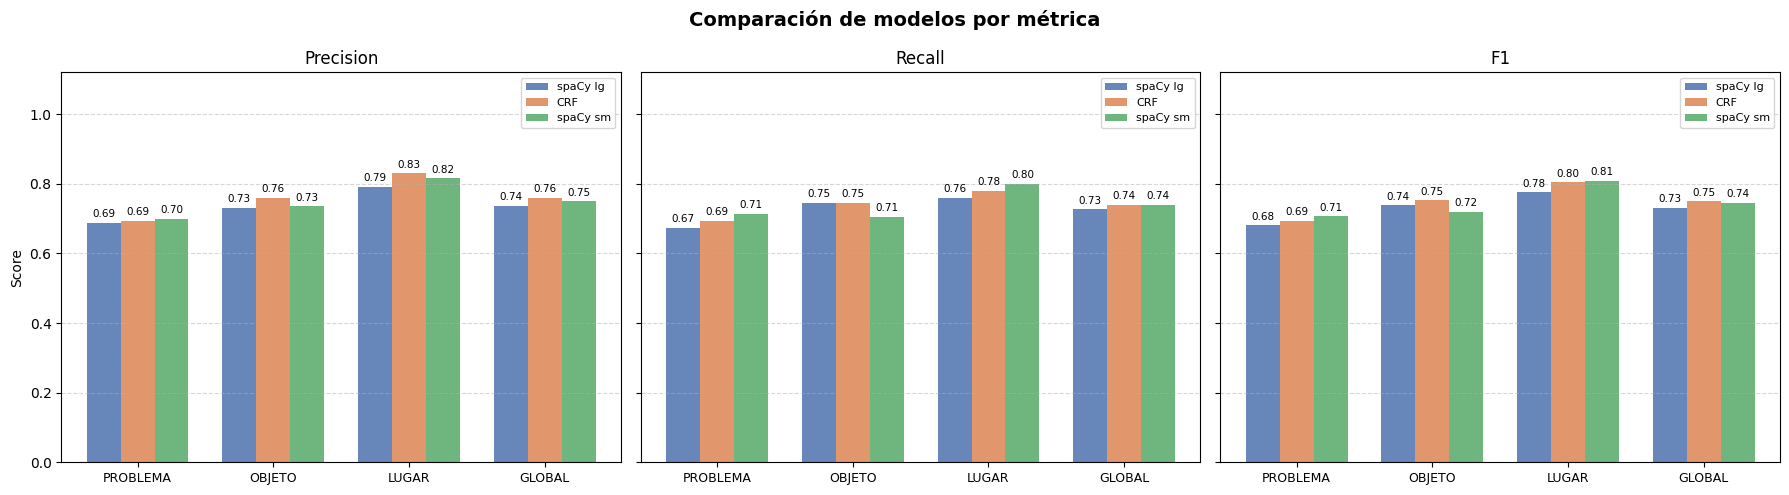

Gráfico guardado como comparacion_metricas.png


In [ ]:
modelos = {
    "spaCy lg": resultados_spacy_lg,
    "CRF":      resultados_crf,
    "spaCy sm": resultados_spacy_sm,
}

colores = ["#4C72B0", "#DD8452", "#55A868"]
etiquetas_plot = LABELS + ["GLOBAL"]
metricas = ["precision", "recall", "f1"]
metrica_labels = ["Precision", "Recall", "F1"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Comparación de modelos por métrica", fontsize=14, fontweight="bold")

x = np.arange(len(etiquetas_plot))
ancho = 0.25

for ax, metrica, m_label in zip(axes, metricas, metrica_labels):
    for i, (nombre, resultados) in enumerate(modelos.items()):
        valores = [resultados[lbl][metrica] for lbl in etiquetas_plot]
        bars = ax.bar(x + i * ancho, valores, ancho, label=nombre, color=colores[i], alpha=0.85)
        # Anotar valores encima de cada barra
        for bar, val in zip(bars, valores):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_title(m_label, fontsize=12)
    ax.set_xticks(x + ancho)
    ax.set_xticklabels(etiquetas_plot, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score" if ax == axes[0] else "")
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("comparacion_metricas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado como comparacion_metricas.png")

Dado que la métrica más importante de maximizar en este proyecto es el recall. En este sentido, observando la gráfica de recall, tanto spaCy sm (verde) como el modelo CRF (naranja) obtienen los mejores valores globales (0.74), empatando en primer lugar y dejando a spaCy lg (0.73) en una posición de desventaja. No obstante, observando la gráfica de F1, el CRF lidera globalmente (0.75) seguido muy de cerca por spaCy sm (0.74), mientras que en la gráfica de precisión el CRF también queda en primer puesto con 0.76.
Con estos resultados, el modelo Conditional Random Field supera a los otros dos en métricas exactas y además presenta el menor costo computacional (tanto en tiempo de entrenamiento e inferencia como en uso de memoria), aunque con la desventaja de que la extracción de features deba hacerse de forma manual, a diferencia de los modelos de spaCy que aprenden las características automáticamente. CRF es el baseline perfecto y, en esta corrida, también el mejor modelo en evaluación exacta.


### Coincidencia parcial: cálculo de métricas

En esta sección re calcularemos Precision, Recall y F1-score pero permitiendo un "desvio" en las predicciones de los índices de inicio y fin de los span detectados, para no penalizar tan fuertemente los modelos por no lograr coincidencias exactas cuando la serie de tokens que capturan y que etiquetan correctamente, son humanamente interpretable.

Se aplicará un umbral de 0.7, lo que significa que al menos el 70% de la entidad real debe coincidir con la predicción para considerar válido el resultado.

In [ ]:
def partial_match(gold, pred, threshold=0.5):
    """
    Determina si una entidad predicha hace match parcial con una gold.
    Retorna:
    - True si hay overlap suficiente y mismo label
    - False en caso contrario
    """

    g_start, g_end, g_label = gold
    p_start, p_end, p_label = pred

    # Deben tener el mismo label
    if g_label != p_label:
        return False

    # Calcular intersección
    inter_start = max(g_start, p_start)
    inter_end = min(g_end, p_end)

    # No hay overlap
    if inter_start >= inter_end:
        return False

    # Longitud de la intersección
    intersection = inter_end - inter_start

    # Longitud de la entidad gold
    gold_length = g_end - g_start

    # Ratio de similitud
    similarity = intersection / gold_length

    return similarity >= threshold

In [ ]:
def evaluar_partial_match(gold_data, predictions, threshold=0.5):
    """
    Evalúa predicciones NER usando Partial Match.
    Retorna:
    - precision
    - recall
    - f1
    """

    tp = 0
    fp = 0
    fn = 0

    # Recorrer ejemplos
    for (text, ann), preds in zip(gold_data, predictions):

        gold_entities = ann["entities"]

        # Para evitar múltiples matches sobre la misma entidad
        matched_gold = [False] * len(gold_entities)
        matched_preds = [False] * len(preds)

        # Comparar cada predicción contra cada gold
        for p_idx, pred in enumerate(preds):

            for g_idx, gold in enumerate(gold_entities):

                # Saltar si esa entidad gold ya fue matcheada
                if matched_gold[g_idx]:
                    continue

                # Verificar partial match
                if partial_match(gold, pred, threshold):

                    matched_preds[p_idx] = True
                    matched_gold[g_idx] = True
                    break

        # Contabilizar métricas
        current_tp = sum(matched_preds)

        current_fp = len(preds) - current_tp

        current_fn = len(gold_entities) - sum(matched_gold)

        tp += current_tp
        fp += current_fp
        fn += current_fn

    # Métricas finales
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    print("=" * 50)
    print(f"PARTIAL MATCH EVALUATION (threshold={threshold})")
    print("=" * 50)
    print(f"TP: {tp}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print("-" * 50)
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    return precision, recall, f1

In [ ]:
# == Evaluar el partial match con un umbral de 0.7 ==
print("spaCy sm")
evaluar_partial_match(data_val, preds_spacy_sm, threshold=0.7)
print("\nspaCy lg")
evaluar_partial_match(data_val, preds_spacy_lg, threshold=0.7)
print("\nCRF")
evaluar_partial_match(data_val, preds_crf, threshold=0.7)

spaCy sm
PARTIAL MATCH EVALUATION (threshold=0.7)
TP: 125
FP: 23
FN: 25
--------------------------------------------------
Precision: 0.8446
Recall:    0.8333
F1-score:  0.8389

spaCy lg
PARTIAL MATCH EVALUATION (threshold=0.7)
TP: 123
FP: 25
FN: 27
--------------------------------------------------
Precision: 0.8311
Recall:    0.8200
F1-score:  0.8255

CRF
PARTIAL MATCH EVALUATION (threshold=0.7)
TP: 121
FP: 25
FN: 29
--------------------------------------------------
Precision: 0.8288
Recall:    0.8067
F1-score:  0.8176


(0.8287671232876712, 0.8066666666666666, 0.8175675675675675)

En este escenario, el mejor modelo, aquel que maximiza el recall y presenta las métricas más altas, es el modelo chico de spaCy (`es_core_news_sm`), seguido de spaCy lg (`es_core_news_lg`) y en último lugar el modelo CRF, que anteriormente estaba en el primer puesto.

### Análisis de errores

#### FP, FN y Errores de tipo

Para entender **en qué se equivoca** el mejor modelo, clasificamos los errores en tres categorías:

| Categoría | Descripción |
|-----------|-------------|
| **FP (falso positivo)** | El modelo predijo una entidad que no existe en gold |
| **FN (falso negativo)** | El modelo no detectó una entidad que sí estaba en gold |
| **Error de tipo** | El modelo encontró el span correcto pero le asignó una etiqueta equivocada |

También visualizamos con `displacy` algunos ejemplos donde hubo errores, mostrando las predicciones del modelo lado a lado con las anotaciones gold.

In [ ]:
# == Imports ==
from collections import Counter

In [ ]:
def analizar_errores(gold_data, pred_spans_list):
    """
    Retorna listas de FP, FN y errores de tipo, junto con
    los ejemplos con mayor cantidad de errores.
    """
    fps, fns, tipo_errs = [], [], []
    ejemplos_con_error = []

    for (text, ann), pred_spans in zip(gold_data, pred_spans_list):
        gold = set((s, e, l) for s, e, l in ann["entities"])
        pred = set(pred_spans)

        gold_positions = {(s, e): l for s, e, l in gold}
        pred_positions = {(s, e): l for s, e, l in pred}

        # Errores de tipo: mismo span, distinta etiqueta
        for pos, g_label in gold_positions.items():
            if pos in pred_positions and pred_positions[pos] != g_label:
                tipo_errs.append({
                    "text": text,
                    "span": text[pos[0]:pos[1]],
                    "gold": g_label,
                    "pred": pred_positions[pos]
                })

        # FP: predicciones que no están en gold
        for span in pred - gold:
            fps.append({"text": text, "span": text[span[0]:span[1]], "label": span[2]})

        # FN: gold que no fue predicho
        for span in gold - pred:
            fns.append({"text": text, "span": text[span[0]:span[1]], "label": span[2]})

        n_errores = len((pred - gold) | (gold - pred))
        if n_errores > 0:
            ejemplos_con_error.append((n_errores, text, gold, pred))

    ejemplos_con_error.sort(reverse=True)
    return fps, fns, tipo_errs, ejemplos_con_error

In [ ]:
def mostar_errores(data, preds):

  fps, fns, tipo_errs, ejemplos_con_error = analizar_errores(data, preds)

  print(f"Falsos Positivos (FP): {len(fps)}")
  print(f"Falsos Negativos (FN): {len(fns)}")
  print(f"Errores de tipo      : {len(tipo_errs)}")

  print("\n── FP más frecuentes (texto del span predicho incorrectamente) ──")
  fp_counter = Counter(e["span"] + f" [{e['label']}]" for e in fps)
  for span, cnt in fp_counter.most_common(10):
      print(f"  {cnt}x  {span}")

  print("\n── FN más frecuentes (entidad gold no detectada) ──")
  fn_counter = Counter(e["span"] + f" [{e['label']}]" for e in fns)
  for span, cnt in fn_counter.most_common(10):
      print(f"  {cnt}x  {span}")

  if tipo_errs:
      print("\n── Errores de tipo ──")
      for e in tipo_errs[:5]:
          print(f"  '{e['span']}' → predicho: {e['pred']} | gold: {e['gold']}")

##### Modelo 1 - spaCy fine-tuneado (`es_core_news_lg`)

In [ ]:
mostar_errores(data_val, preds_spacy_lg)

Falsos Positivos (FP): 39
Falsos Negativos (FN): 41
Errores de tipo      : 1

── FP más frecuentes (texto del span predicho incorrectamente) ──
  2x  esta manchada [PROBLEMA]
  2x  entrada [LUGAR]
  2x  portero [OBJETO]
  1x  canilla [OBJETO]
  1x  vidroi [OBJETO]
  1x  parque después de cursar [LUGAR]
  1x  reja de entrada [LUGAR]
  1x  candado roto [PROBLEMA]
  1x  rayas [PROBLEMA]
  1x  monitor de la pc [OBJETO]

── FN más frecuentes (entidad gold no detectada) ──
  2x  la entrada [LUGAR]
  2x  portero electrico [OBJETO]
  1x  la canilla [OBJETO]
  1x  un vidroi root [PROBLEMA]
  1x  reja [OBJETO]
  1x  entrada [LUGAR]
  1x  tiene el candado roto [PROBLEMA]
  1x  monitor [OBJETO]
  1x  tiene rayas [PROBLEMA]
  1x  se tildo [PROBLEMA]

── Errores de tipo ──
  'puerta de entrada' → predicho: LUGAR | gold: OBJETO


Total de errores (cantidad de FP y FN): 80

Se observa que el modelo spaCy lg comete más errores al detectar la entidad correcta en ejemplos que incluyen las frases "esta manchada", "entrada" y "portero", todas con dos ocurrencias en los falsos positivos. La ambigüedad de "entrada" y "portero" resulta lógica: "entrada" puede referirse a un LUGAR, como en "puerta de entrada", pero en un mensaje como "la puerta de entrada no funciona" estaría haciendo referencia a un OBJETO; "portero" puede aludir a un objeto, como "el portero eléctrico", o simplemente a una persona, en cuyo caso no tendría ninguna entidad asignable dentro del dominio definido ya que PERSONA no forma parte de las entidades consideradas en este proyecto. Por su parte, "esta manchada" representa un caso de ambigüedad contextual: dependiendo del mensaje, puede interpretarse como un PROBLEMA o no ser una entidad relevante. En esta corrida, la cantidad de falsos negativos (41) supera levemente a los falsos positivos (39), lo que indica que el modelo omite más entidades de las que detecta incorrectamente.

##### Modelo 2 - CRF

In [ ]:
mostar_errores(data_val, preds_crf)

Falsos Positivos (FP): 35
Falsos Negativos (FN): 39
Errores de tipo      : 2

── FP más frecuentes (texto del span predicho incorrectamente) ──
  3x  pc [OBJETO]
  2x  entrada [LUGAR]
  2x  no cierra [PROBLEMA]
  1x  no para [PROBLEMA]
  1x  canilla [OBJETO]
  1x  desbordado [PROBLEMA]
  1x  reja de entrada [LUGAR]
  1x  rayas [PROBLEMA]
  1x  todo bolcado [PROBLEMA]
  1x  tildo la pc [PROBLEMA]

── FN más frecuentes (entidad gold no detectada) ──
  2x  la entrada [LUGAR]
  2x  portero electrico [OBJETO]
  2x  cerradura [OBJETO]
  1x  no para de perder [PROBLEMA]
  1x  la canilla [OBJETO]
  1x  un vidroi root [PROBLEMA]
  1x  esta desbordado [PROBLEMA]
  1x  reja [OBJETO]
  1x  entrada [LUGAR]
  1x  tiene rayas [PROBLEMA]

── Errores de tipo ──
  'cosina' → predicho: OBJETO | gold: LUGAR
  'puerta de entrada' → predicho: LUGAR | gold: OBJETO


Total de errores (cantidad de FP y FN): 74

En este caso, el error más frecuente del modelo es la detección incorrecta de "pc" como OBJETO (3 ocurrencias en FP), lo cual puede explicarse por la ambigüedad de este término en el contexto de los mensajes. Al igual que en el modelo spaCy lg, "entrada" también resulta problemática (2x en FP). Como en el primer modelo, las entidades "la entrada" y "portero eléctrico" no fueron detectadas por el modelo en la mayoría de los casos (2x en FN cada una).

##### Modelo 3 – spaCy fine-tuneado (`es_core_news_sm`)

In [ ]:
mostar_errores(data_val, preds_spacy_sm)

Falsos Positivos (FP): 37
Falsos Negativos (FN): 39
Errores de tipo      : 1

── FP más frecuentes (texto del span predicho incorrectamente) ──
  2x  esta manchada [PROBLEMA]
  2x  entrada [LUGAR]
  2x  portero [OBJETO]
  2x  no cierra [PROBLEMA]
  1x  canilla [OBJETO]
  1x  reja de entrada [LUGAR]
  1x  candado [OBJETO]
  1x  roto [PROBLEMA]
  1x  rayas [PROBLEMA]
  1x  monitor de la pc [OBJETO]

── FN más frecuentes (entidad gold no detectada) ──
  2x  la entrada [LUGAR]
  2x  portero electrico [OBJETO]
  1x  la canilla [OBJETO]
  1x  reja [OBJETO]
  1x  entrada [LUGAR]
  1x  tiene el candado roto [PROBLEMA]
  1x  monitor [OBJETO]
  1x  tiene rayas [PROBLEMA]
  1x  pc [OBJETO]
  1x  se tildo [PROBLEMA]

── Errores de tipo ──
  'puerta de entrada' → predicho: LUGAR | gold: OBJETO


Total de errores (cantidad de FP y FN): 76.

Como en todos los casos, "entrada" y "portero" son incorrectamente detectados por el modelo (2x en FP cada uno). Además, este modelo presenta dificultades para identificar la entidad correcta de la frase "esta manchada" (2x en FP) y "no cierra" (2x en FP).

#### Visualización displacy de errores

Mostramos los 5 ejemplos con más errores. Las entidades coloreadas son las **predicciones del modelo**; debajo se imprime el gold para comparar.

In [ ]:
# == Imports ==
from spacy import displacy
from spacy.tokens import Span
from IPython.display import display, HTML

##### Modelo 1 - spaCy fine-tuneado (`es_core_news_lg`)

In [ ]:
colores_ent = {
    "PROBLEMA": "#ff9999",
    "OBJETO": "#99ccff",
    "LUGAR": "#99ff99"
}

def displacy_errors(data, preds):

    fps, fns, tipo_errs, ejemplos_con_error = analizar_errores(data, preds)

    for n_err, text, gold_spans, pred_spans in ejemplos_con_error[:5]:

        print(f"\n{'─'*60}")
        print(f"Texto : {text}")
        print(f"Gold  : {sorted(gold_spans)}")
        print(f"Pred  : {sorted(pred_spans)}")

        # Crear doc vacío (sin ejecutar NER)
        doc = nlp_ft.make_doc(text)

        ents = []

        # Agregar spans predichos manualmente
        for start, end, label in pred_spans:

            span = doc.char_span(
                start,
                end,
                label=label,
                alignment_mode="contract"
            )

            if span is not None:
                ents.append(span)

        doc.ents = ents

        # Renderizar entidades
        html = displacy.render(
            doc,
            style="ent",
            jupyter=False,
            options={"colors": colores_ent}
        )

        display(HTML("<b>Predicción del modelo:</b><br>" + html))

In [ ]:
displacy_errors(data_val, preds_spacy_lg)


────────────────────────────────────────────────────────────
Texto : vine a la facu y vi que la reja de entrada tiene el candado roto
Gold  : [(27, 31, 'OBJETO'), (35, 42, 'LUGAR'), (43, 64, 'PROBLEMA')]
Pred  : [(27, 42, 'LUGAR'), (52, 64, 'PROBLEMA')]



────────────────────────────────────────────────────────────
Texto : vibracion excesiva en el motor del asensor del ala norte
Gold  : [(0, 18, 'PROBLEMA'), (25, 42, 'OBJETO'), (47, 56, 'LUGAR')]
Pred  : [(0, 18, 'PROBLEMA'), (25, 30, 'OBJETO'), (35, 56, 'LUGAR')]



────────────────────────────────────────────────────────────
Texto : los cables del rack de comunicaciones estan todos pelados
Gold  : [(4, 10, 'OBJETO'), (15, 37, 'LUGAR'), (44, 57, 'PROBLEMA')]
Pred  : [(4, 37, 'OBJETO')]



────────────────────────────────────────────────────────────
Texto : el portero electrico de la entrada no da tono
Gold  : [(3, 20, 'OBJETO'), (24, 34, 'LUGAR'), (35, 45, 'PROBLEMA')]
Pred  : [(3, 10, 'OBJETO'), (27, 34, 'LUGAR'), (35, 45, 'PROBLEMA')]



────────────────────────────────────────────────────────────
Texto : el monitor de la pc del aula 04-05 tiene rayas
Gold  : [(3, 10, 'OBJETO'), (24, 34, 'LUGAR'), (35, 46, 'PROBLEMA')]
Pred  : [(3, 19, 'OBJETO'), (24, 34, 'LUGAR'), (41, 46, 'PROBLEMA')]


##### Modelo 2 - CRF

In [ ]:
displacy_errors(data_val, preds_crf)


────────────────────────────────────────────────────────────
Texto : Se callo la cortina en el salon de actos, el que esta al fondo
Gold  : [(3, 11, 'PROBLEMA'), (12, 19, 'OBJETO'), (26, 62, 'LUGAR')]
Pred  : [(0, 8, 'PROBLEMA'), (12, 19, 'OBJETO'), (26, 41, 'LUGAR'), (54, 62, 'PROBLEMA')]



────────────────────────────────────────────────────────────
Texto : vine a la facu y vi que la puerta de entrada no cierra bien
Gold  : [(27, 44, 'OBJETO'), (45, 59, 'PROBLEMA')]
Pred  : [(27, 44, 'LUGAR'), (45, 54, 'PROBLEMA')]



────────────────────────────────────────────────────────────
Texto : hola recien entre al bañp de hombres y la canilla no para de perder
Gold  : [(21, 36, 'LUGAR'), (39, 49, 'OBJETO'), (50, 67, 'PROBLEMA')]
Pred  : [(21, 36, 'LUGAR'), (42, 49, 'OBJETO'), (50, 57, 'PROBLEMA')]



────────────────────────────────────────────────────────────
Texto : vine a la facu y vi que la reja de entrada tiene el candado roto
Gold  : [(27, 31, 'OBJETO'), (35, 42, 'LUGAR'), (43, 64, 'PROBLEMA')]
Pred  : [(27, 42, 'LUGAR'), (43, 64, 'PROBLEMA')]



────────────────────────────────────────────────────────────
Texto : no hay luz en el aula 02-10
Gold  : [(0, 10, 'PROBLEMA'), (17, 27, 'LUGAR')]
Pred  : [(0, 6, 'PROBLEMA'), (7, 10, 'OBJETO'), (17, 27, 'LUGAR')]


##### Modelo 3 - spaCy fine-tuneado (`es_core_news_sm`)

In [ ]:
displacy_errors(data_val, preds_spacy_sm)


────────────────────────────────────────────────────────────
Texto : vine a la facu y vi que la reja de entrada tiene el candado roto
Gold  : [(27, 31, 'OBJETO'), (35, 42, 'LUGAR'), (43, 64, 'PROBLEMA')]
Pred  : [(27, 42, 'LUGAR'), (52, 59, 'OBJETO'), (60, 64, 'PROBLEMA')]



────────────────────────────────────────────────────────────
Texto : vine a la facu y vi que la puerta de entrada no cierra bien
Gold  : [(27, 44, 'OBJETO'), (45, 59, 'PROBLEMA')]
Pred  : [(27, 44, 'LUGAR'), (45, 54, 'PROBLEMA')]



────────────────────────────────────────────────────────────
Texto : los cables del rack de comunicaciones estan todos pelados
Gold  : [(4, 10, 'OBJETO'), (15, 37, 'LUGAR'), (44, 57, 'PROBLEMA')]
Pred  : [(4, 43, 'OBJETO')]



────────────────────────────────────────────────────────────
Texto : el portero electrico de la entrada no da tono
Gold  : [(3, 20, 'OBJETO'), (24, 34, 'LUGAR'), (35, 45, 'PROBLEMA')]
Pred  : [(3, 10, 'OBJETO'), (27, 34, 'LUGAR'), (35, 45, 'PROBLEMA')]



────────────────────────────────────────────────────────────
Texto : el monitor de la pc del aula 04-05 tiene rayas
Gold  : [(3, 10, 'OBJETO'), (24, 34, 'LUGAR'), (35, 46, 'PROBLEMA')]
Pred  : [(3, 19, 'OBJETO'), (24, 34, 'LUGAR'), (41, 46, 'PROBLEMA')]


### Distribución de errores por etiqueta

Este gráfico muestra **cuántos FP y FN** tiene cada modelo **por etiqueta**, lo que permite identificar qué tipo de entidad es más difícil de detectar para cada enfoque.

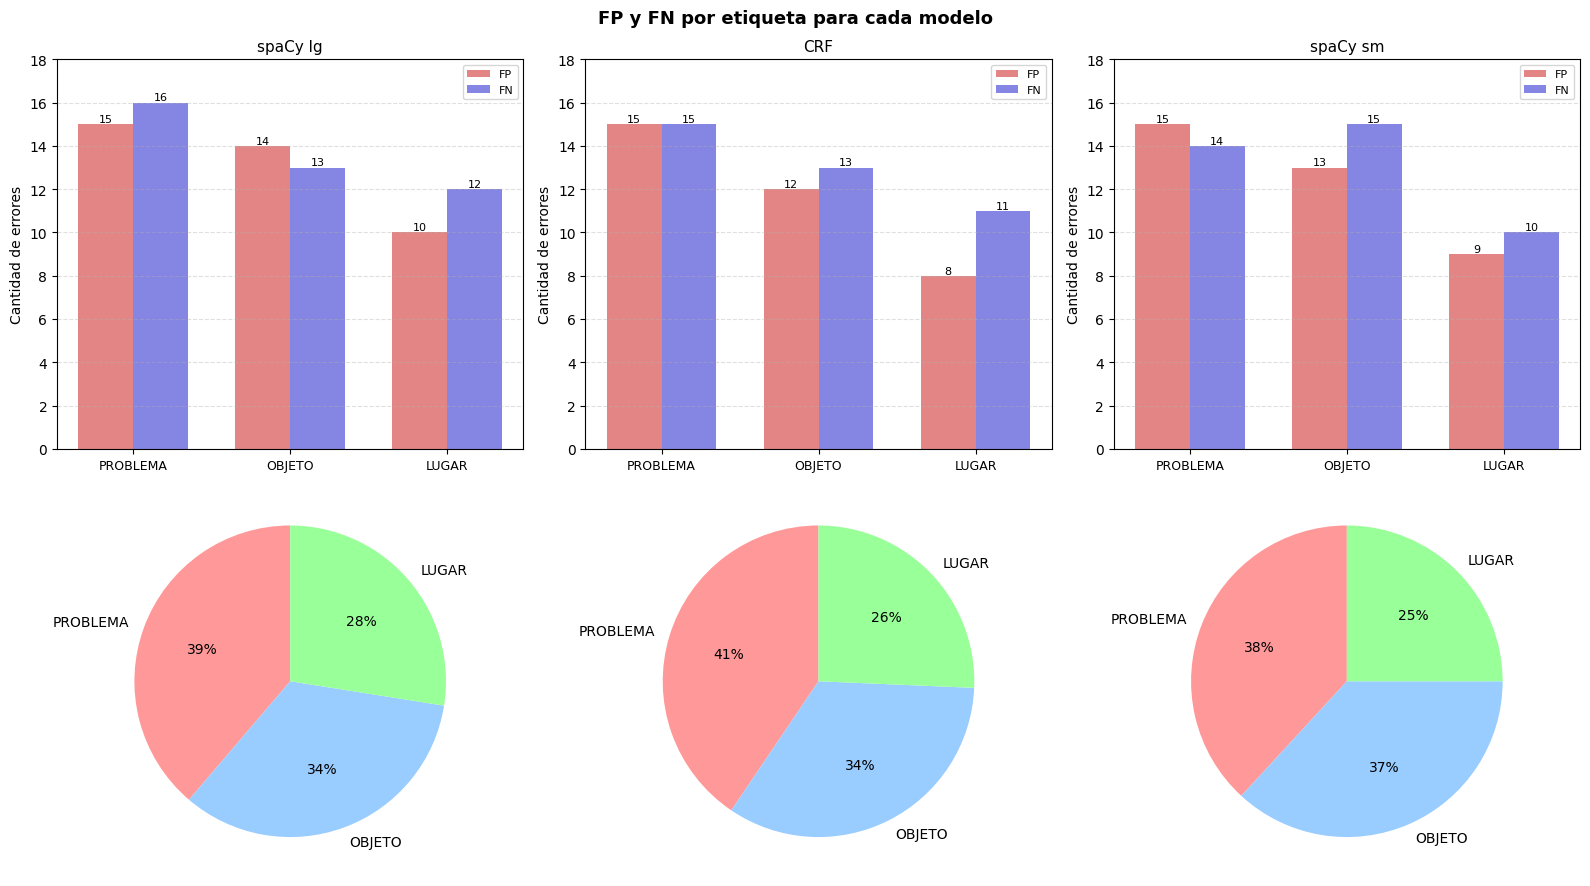

Gráfico guardado como distribucion_errores.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("FP y FN por etiqueta para cada modelo", fontsize=13, fontweight="bold")

todos_modelos = [
    ("spaCy lg", resultados_spacy_lg),
    ("CRF",      resultados_crf),
    ("spaCy sm", resultados_spacy_sm),
]

# Calcular máximo global para compartir escala Y
max_y = 0

for _, res in todos_modelos:

    fps = [res[l]["fp"] for l in LABELS]
    fns = [res[l]["fn"] for l in LABELS]

    max_y = max(max_y, max(fps + fns))

# Margen visual superior
max_y += 2

for col, (nombre, res) in enumerate(todos_modelos):
    fps_por_label = [res[l]["fp"] for l in LABELS]
    fns_por_label = [res[l]["fn"] for l in LABELS]

    # Fila 0: barras agrupadas FP vs FN
    ax_bar = axes[0][col]

    x = np.arange(len(LABELS))
    width = 0.35

    # Barras FP
    ax_bar.bar(x - width/2, fps_por_label, width, label="FP", color="#e07070", alpha=0.85)

    # Barras FN
    ax_bar.bar(x + width/2, fns_por_label, width, label="FN", color="#7070e0", alpha=0.85)

    ax_bar.set_title(nombre, fontsize=11)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(LABELS, fontsize=9)
    ax_bar.set_ylabel("Cantidad de errores")
    ax_bar.set_ylim(0, max_y)

    ax_bar.legend(fontsize=8)
    ax_bar.grid(axis="y", linestyle="--", alpha=0.4)

    # Anotar valores individuales
    for i, (fp_v, fn_v) in enumerate(zip(fps_por_label, fns_por_label)):

        if fp_v > 0:
            ax_bar.text(i - width/2, fp_v + 0.1, str(fp_v), ha="center", fontsize=8)

        if fn_v > 0:
            ax_bar.text(i + width/2, fn_v + 0.1, str(fn_v), ha="center", fontsize=8)

    # Fila 1: torta de distribución de errores entre etiquetas
    ax_pie = axes[1][col]
    errores_totales = [fp + fn for fp, fn in zip(fps_por_label, fns_por_label)]
    if sum(errores_totales) > 0:
        ax_pie.pie(errores_totales, labels=LABELS, autopct="%1.0f%%",
                   colors=["#ff9999", "#99ccff", "#99ff99"], startangle=90)
    else:
        ax_pie.text(0.5, 0.5, "Sin errores", ha="center", va="center", fontsize=10)
        ax_pie.axis("off")

plt.tight_layout()
plt.savefig("distribucion_errores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado como distribucion_errores.png")

En los gráficos de torta se puede observar que la entidad que más problemas causa a los modelos es, irónicamente, la etiqueta PROBLEMA. Esto se explica por la ambigüedad y variabilidad lingüística y contextual en la que los usuarios pueden describir incidencias. Mediante expresiones muy diferentes se puede describir lo mismo, como por ejemplo “no funciona” y “no anda”, como así también describir casos diferentes con alta variabilidad en las frases, como “sin tinta” o “pierde agua”. PROBLEMA es la entidad más difícil de segmentar y clasificar porque no cae en un patrón estructurado como sí sucede con LUGAR, que se observa que concentra la menor proporción de errores en todos los modelos. Esto puede deberse a que el lugar del hechos suele estar descrito como “aula 05-04”, “aula 02”, “biblioteca”, “laboratorio”, “entrada”, facilitando a los modelos capturar correctamente los índices y etiquetas de las secuencias.

En los gráficos de barras podemos observar que el modelo que concentra la menor cantidad de falsos negativos son spaCy sm y CRF, ambos con 39 falsos negativos en total (se suma la cantidad de FN por entidad, para cada modelo), mientras que spaCy lg muestra 41 errores tipo II. Esto hace a los modelos más simples muy competitivos en este proyecto, dado que con menos recursos se consiguen mejores resultados (spaCy lg es un modelo más grande y, por ende, más pesado a comparación de su versión pequeña y la opción probabilística CRF).

## 8. Conclusiones

#### Resultados de los modelos
En términos generales, los tres modelos evaluados lograron resultados satisfactorios para la extracción automática de entidades dentro del dominio propuesto, aunque con diferencias claras en su capacidad de generalización y detección de entidades relevantes.

Por un lado, el modelo basado en CRF obtuvo el mejor desempeño global en métricas exactas (F1=0.7500), destacándose especialmente en precisión (0.7603) y en la entidad LUGAR (F1=0.8041). El modelo spaCy `es_core_news_sm` quedó en segundo lugar en métricas exactas (F1=0.7450), igualando el recall del CRF. Finalmente, el modelo spaCy entrenado sobre `es_core_news_lg` obtuvo el menor desempeño global en esta corrida (F1=0.7315), aunque con un recall de 0.7267 que sigue siendo competitivo.

Por otro lado, bajo el criterio de evaluación de coincidencia parcial, los modelos de spaCy superaron al CRF, en especial el modelo spaCy sm que superó al resto con un F1-score de 0.8389. Esto sugiere que los enfoques poseen fortalezas diferentes. El modelo CRF demostró una mayor precisión en la delimitación exacta de las entidades, probablemente debido a que las entidades del dataset presentan patrones estructurados y repetitivos, lo que favorece a modelos estadísticos basados en features locales. En cambio, los modelos de spaCy, aunque cometían pequeños errores en los índices de inicio y fin de las entidades, lograban identificar correctamente la región semántica correspondiente gracias a su capacidad de representación contextual. Bajo coincidencia exacta, estos pequeños desvíos eran penalizados como errores completos; sin embargo, el criterio de coincidencia parcial permitió reconocer predicciones con superposición significativa respecto de la entidad real. Como resultado, los modelos neuronales mostraron una mejor capacidad de detección semántica aproximada, mientras que el CRF conservó una ventaja en precisión estructural y delimitación exacta de spans.

En conclusión, considerando la evaluación de coincidencia exacta, el modelo CRF resulta el más adecuado para utilizar en producción por su mejor desempeño de métricas y su menor costo computacional. No obstante, si se prioriza la robustez ante pequeños errores de segmentación, el modelo spaCy `es_core_news_sm` representa una alternativa muy sólida al liderar en la evaluación de coincidencia parcial.

#### Limitaciones
Entendemos que una de las principales limitaciones de este proyecto se encuentra en el conjunto de datos utilizado para el entrenamiento y evaluación de los modelos. Al tratarse de un dataset sintético, las expresiones incluidas no representan completamente la diversidad lingüística que podría aparecer en un entorno real de uso. En producción, los usuarios podrían emplear expresiones coloquiales, abreviaciones, errores ortográficos, mensajes poco estructurados, distintas formas de describir un mismo problema, emplear múltiples oraciones, información redundante o descripciones más extensas del incidente, incrementando la complejidad de la tarea de segmentación y clasificación de entidades, afectando la capacidad de generalización del sistema. No obstante, durante la construcción del dataset se intentó incorporar cierta variabilidad lingüística, incluyendo diferentes formas de expresar incidencias, mensajes más informales e incluso ejemplos sin entidades etiquetadas, con el objetivo de aproximar parcialmente las condiciones reales de utilización del sistema.

Se podría explorar el rendimiento de los modelos spaCy haciendo cambios en sus hiperparámetros para evitar el drástico sobreajuste que presentaron, pero consideramos que la solución principal sería el aumento del tamaño y la complejidad del dataset. Además, el CRF funcionó como un modelo baseline presentando un rendimiento satisfactorio, por lo que no sería pertinente implementar modelos más complejos cuando el que presenta menor costo computacional funciona efectiva y eficientemente.

#### Próximos pasos
Como trabajo futuro, el primer paso sería aumentar el tamaño del dataset y, en lo posible, incorporar ejemplos de situaciones reales de uso.

Posteriormente, podría explorarse el uso de modelos basados en arquitecturas Transformer, como BERT, capaces de generar embeddings contextuales mediante mecanismos de self-attention. A diferencia de los enfoques utilizados en este trabajo, estos modelos construyen representaciones considerando simultáneamente el contexto completo de la secuencia, permitiendo capturar relaciones semánticas y dependencias lingüísticas más complejas. Esto podría servir para detectar entidades en mensajes ambiguos o con alta variabilidad lingüística, como PROBLEMA, donde la interpretación depende fuertemente del contexto.

Finalmente, también podría evaluarse el uso de modelos de lenguaje de gran escala (LLMs) para realizar tareas de extracción de entidades mediante prompting e in-context learning. En este enfoque, el modelo recibe ejemplos de entradas y salidas esperadas dentro del prompt, permitiéndole adaptarse dinámicamente al dominio sin necesidad de reentrenamiento explícito. Esto podría facilitar la incorporación rápida de nuevos patrones, vocabulario o tipos de incidentes observados en producción, especialmente en este escenario donde resulta difícil generar grandes volúmenes de datos anotados.

#### Pregunta final
> *¿Por qué un modelo neuronal, complejo y potente tiene peor rendimiento que un modelo estadístico simple?*

Consideramos que esta pregunta resume el análisis realizado en el presente trabajo y que puede derivar en un debate de respuestas interesantes.
